In [2]:
import matplotlib.pyplot as plt
import numpy as np
import random
import networkx as nx 

## FASE 1.1 La funcion de Collatz (ESENCIAL PARA ESTA FASE)

Definimos una funcion que recibe un numero entero positivo y devuelve
la trayectoria completa hasta llegar a 1.

In [13]:
def collatz(n):
    """Genera la trayectoria de Collatz partiendo desde n."""
    trayectoria = [n]
    while n != 1:
        if n % 2 == 0:
            n = n // 2
        else:
            n = 3 * n + 1
        trayectoria.append(n)
    return trayectoria

sacar informacion de altitud y tiempo de vuelo


In [ ]:
def info_collatz(n):
    trayectoria = collatz(n)
    pasos = len(trayectoria) - 1
    maximo = max(trayectoria)
    return pasos, maximo
pasos, maximo = info_collatz(100) #se reemplaza el 27 por cualquier numero para ver sus datos esto lo escribi yio 

print("Tiempo de vuelo T(n):", pasos)
print("Altitud máxima A(n):", maximo)

Tiempo de vuelo T(n): 25
Altitud máxima A(n): 100


## FASE 3 ARBOL DE COLLATZ INVERSO

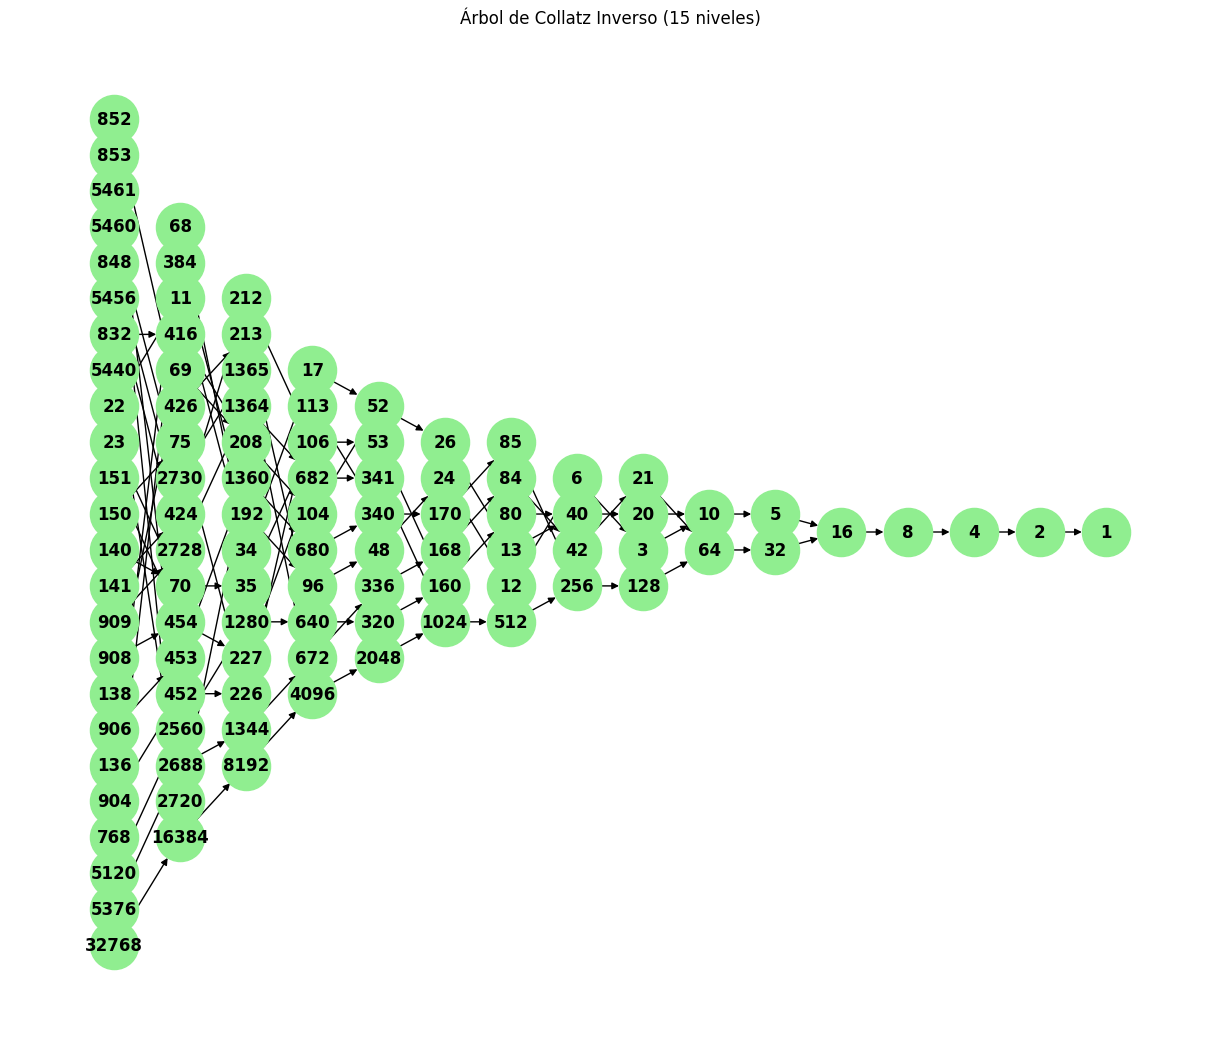

In [7]:

import networkx as nx
import matplotlib.pyplot as plt

# 1. Configuración
nodo_inicial = 1
niveles = 15 # Ajusta el rango de expansión aquí
G = nx.DiGraph()
nodos_actuales = [nodo_inicial]

# 2. Construcción del Árbol Inverso
for _ in range(niveles):
    proximos_nodos = []
    for n in nodos_actuales:
        # Regla 1: Siempre se puede multiplicar por 2
        p1 = n * 2
        if not G.has_node(p1):
            G.add_edge(p1, n) # La flecha apunta al sucesor para que sea inverso
            proximos_nodos.append(p1)
            
        # Regla 2: Solo si (n-1) es divisible por 3 y el resultado es impar > 1
        # Esto asegura que trabajes solo con los enteros que pertenecen a la conjetura
        if (n - 1) % 3 == 0:
            p2 = (n - 1) // 3
            if p2 > 1 and p2 % 2 != 0:
                if not G.has_node(p2):
                    G.add_edge(p2, n)
                    proximos_nodos.append(p2)
                    
    nodos_actuales = proximos_nodos

# 3. Visualización con forma de árbol
plt.figure(figsize=(12, 10))

# multipartite_layout simula la estructura de árbol si asignamos capas
for layer, nodes in enumerate(nx.topological_generations(G)):
    for node in nodes:
        G.nodes[node]["layer"] = layer

pos = nx.multipartite_layout(G, subset_key="layer")

# Dibujar
nx.draw(G, pos, with_labels=True, node_color="lightgreen", 
        node_size=1200, font_weight="bold", arrows=True)
plt.title(f"Árbol de Collatz Inverso ({niveles} niveles)")
plt.show()

